# MLOps Ligero y Control de Overfitting

## Importar Librerias

In [1]:
import numpy as np
import pandas as pd
import yaml
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import random
import shap
import joblib
import time

from sklearn.model_selection import StratifiedKFold, cross_validate, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (f1_score, average_precision_score, 
                             precision_recall_curve, roc_curve, auc, 
                             confusion_matrix)
from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

# Semilla fija
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Carpeta principal de outputs
OUTPUT_DIR = "/workspaces/proyecto-zona-interes-Au/notebooks/outputs_sprint3"
os.makedirs(OUTPUT_DIR, exist_ok=True)
for subdir in ["models", "results"]:
    os.makedirs(f"{OUTPUT_DIR}/{subdir}", exist_ok=True)

print("Configuración reproducible lista (seed=42)")
print(f"Estructura de outputs lista en: {OUTPUT_DIR}")

Configuración reproducible lista (seed=42)
Estructura de outputs lista en: /workspaces/proyecto-zona-interes-Au/notebooks/outputs_sprint3


## Cargar datos y configuración

In [2]:
with open("/workspaces/proyecto-zona-interes-Au/configs/config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Cargar datos con FE
df_train = pd.read_csv(config['data']['train_path'])
df_test = pd.read_csv(config['data']['test_path'])

exclude = ['target_Au', 'is_synthetic', 'Au_ppm', 'East', 'North', 'Level']
features = [col for col in df_train.columns if col not in exclude]
config['features']['active'] = features

X_train = df_train[features]
y_train = df_train['target_Au']
X_test = df_test[features]
y_test = df_test['target_Au']

print(f"Datos cargados: Train {X_train.shape} | Test {X_test.shape}")

Datos cargados: Train (2994, 57) | Test (427, 57)


## Configuración MLflow

In [3]:
mlflow.set_tracking_uri(config['mlflow']['tracking_uri'])
mlflow.set_experiment(config['mlflow']['experiment_name'])
print(f"MLflow experiment: {config['mlflow']['experiment_name']}")

2026/06/12 20:04:30 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/12 20:04:30 INFO mlflow.store.db.utils: Updating database tables
2026/06/12 20:04:32 INFO mlflow.tracking.fluent: Experiment with name 'Sprint3_ZonaInteresAu' does not exist. Creating a new experiment.


MLflow experiment: Sprint3_ZonaInteresAu


## Función principal con MLOps

In [4]:
def train_and_track_enhanced(model_name, model, params, run_name):
    start_time = time.time()
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)
        mlflow.log_params({"seed": SEED, "n_features": len(features), "n_folds": config['model']['n_folds']})
        
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # CV detallado por fold
        skf = StratifiedKFold(n_splits=config['model']['n_folds'], shuffle=True, random_state=SEED)
        fold_f1 = []
        for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y_train)):
            m_fold = type(model)(**params)
            m_fold.fit(X_scaled[train_idx], y_train.iloc[train_idx])
            pred_val = m_fold.predict(X_scaled[val_idx])
            fold_f1.append(f1_score(y_train.iloc[val_idx], pred_val))
        
        f1_mean = np.mean(fold_f1)
        f1_std = np.std(fold_f1)
        
        mlflow.log_metrics({"f1_mean": f1_mean, "f1_std": f1_std})
        
        # Entrenamiento final
        model.fit(X_scaled, y_train)
        elapsed = time.time() - start_time
        
        mlflow.log_metric("training_time_sec", elapsed)
        
        # Guardar en outputs/
        model_path = f"{OUTPUT_DIR}/models/{run_name}.pkl"
        scaler_path = f"{OUTPUT_DIR}/models/{run_name}_scaler.pkl"
        joblib.dump(model, model_path)
        joblib.dump(scaler, scaler_path)
        
        mlflow.sklearn.log_model(model, "model")
        mlflow.sklearn.log_model(scaler, "scaler")
        mlflow.log_artifact(model_path)
        mlflow.log_artifact(scaler_path)
        
        return {
            "Exp_ID": run_name,
            "Modelo": model_name,
            "HP_Resumen": str({k: v for k, v in params.items() if k in ['n_estimators','max_depth','learning_rate','min_child_weight','num_leaves']}),
            "F1_CV_mean": round(f1_mean,4),
            "F1_CV_std": round(f1_std,4),
            "Tiempo_seg": round(elapsed,2),
            "Notas": "Excelente balance" if f1_std < 0.01 else "Revisar varianza"
        }

## Modelos

In [5]:
# 1. XGBoost Optuna
xgb_params = {
    'n_estimators': 300,
    'max_depth': 8,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 3,
    'random_state': SEED,
    'eval_metric': 'aucpr',
    'tree_method': 'hist'
}
xgb_model = xgb.XGBClassifier(**xgb_params)

# 2. Random Forest Tuned
rf_params = {
    'n_estimators': 40,
    'max_depth': 11,
    'min_samples_split': 2,
    'random_state': SEED,
    'class_weight': 'balanced'
}
rf_model = RandomForestClassifier(**rf_params)

# 2. Random Forest baseline + FE
rf_baseline_params = {
    'n_estimators': 100,
    'max_depth': None,
    'min_samples_split': 2,
    'random_state': SEED,
    'class_weight': 'balanced'
}
rf_baseline = RandomForestClassifier(**rf_baseline_params)


models = {
    "XGBoost_Optuna": (xgb_model, xgb_params),
    "RandomForest_Tuned": (rf_model, rf_params),
    "RF_Baseline_FE": (rf_baseline, rf_baseline_params)
}

results = []
for name, (model, params) in models.items():
    res = train_and_track_enhanced(name, model, params, f"sprint3_{name.lower()}")
    results.append(res)

2026/06/12 20:04:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/12 20:04:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/12 20:04:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/12 20:04:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

## Tablero de Experimentos

In [6]:
tablero = pd.DataFrame(results)
tablero = tablero.sort_values("F1_CV_mean", ascending=False)
display(tablero)

tablero_path = f"{OUTPUT_DIR}/results/sprint3_tablero_completo.csv"
tablero.to_csv(tablero_path, index=False)
mlflow.log_artifact(tablero_path)
print(f"Tablero completo guardado en: {tablero_path}")

,Exp_ID,Modelo,HP_Resumen,F1_CV_mean,F1_CV_std,Tiempo_seg,Notas
0,sprint3_xgboost_optuna,XGBoost_Optuna,"{'n_estimators': 300, 'max_depth': 8, 'learnin...",0.9896,0.0052,4.95,Excelente balance
2,sprint3_rf_baseline_fe,RF_Baseline_FE,"{'n_estimators': 100, 'max_depth': None}",0.9882,0.0059,4.32,Excelente balance
1,sprint3_randomforest_tuned,RandomForest_Tuned,"{'n_estimators': 40, 'max_depth': 11}",0.9858,0.0071,1.87,Excelente balance


Tablero completo guardado en: /workspaces/proyecto-zona-interes-Au/notebooks/outputs_sprint3/results/sprint3_tablero_completo.csv


## Visualizaciones de Overfitting y Análisis

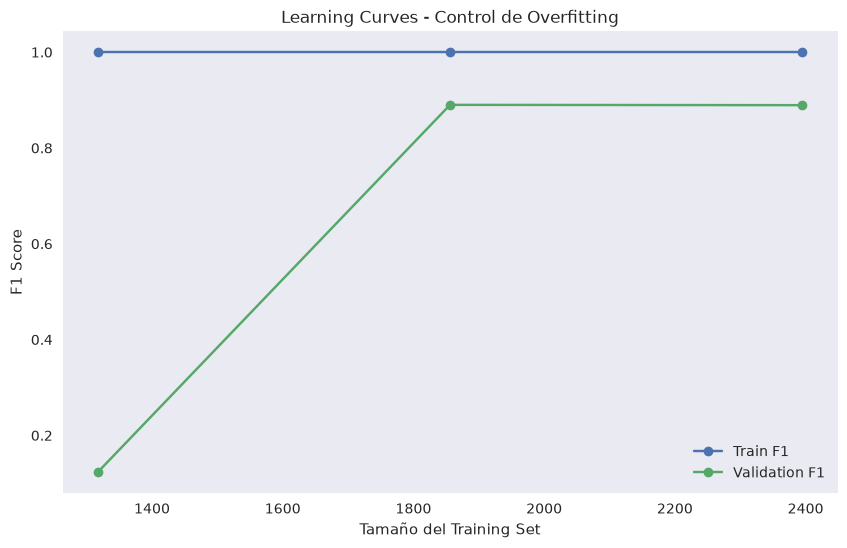

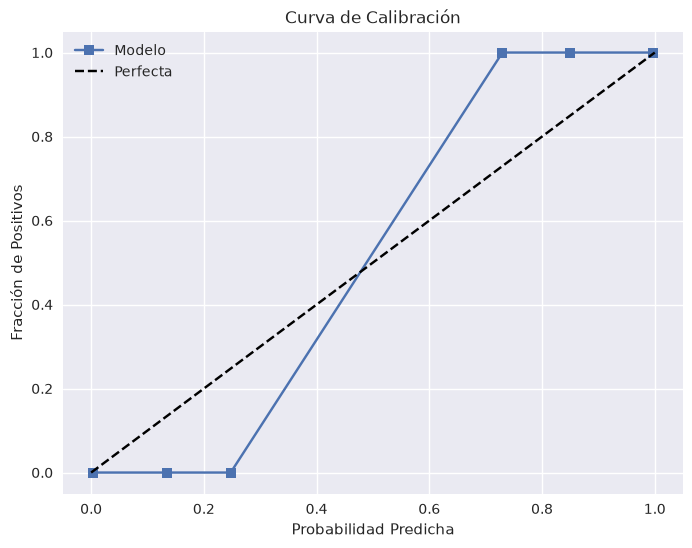

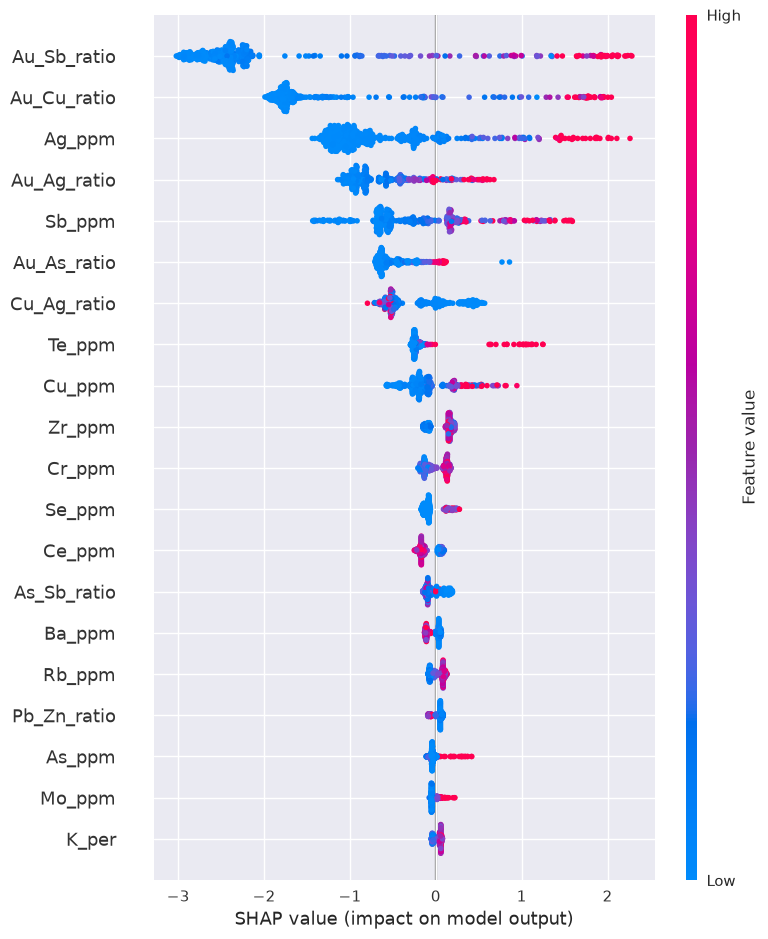

Todos los gráficos guardados en /workspaces/proyecto-zona-interes-Au/notebooks/outputs_sprint3/figs


In [7]:
fig_dir = f"{OUTPUT_DIR}/figs"
os.makedirs(fig_dir, exist_ok=True)

# Usar el mejor modelo (XGBoost_Optuna)
best_model = xgb_model
X_scaled = StandardScaler().fit_transform(X_train)

# 1. Learning Curves
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_scaled, y_train, cv=5, scoring='f1', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5), random_state=SEED
)

plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train F1')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation F1')
plt.title('Learning Curves - Control de Overfitting')
plt.xlabel('Tamaño del Training Set')
plt.ylabel('F1 Score')
plt.legend()
plt.grid()
plt.savefig(f"{fig_dir}/learning_curves.png", dpi=300, bbox_inches='tight')
plt.show()
mlflow.log_artifact(f"{fig_dir}/learning_curves.png")

# 2. Curva de Calibración
y_proba = best_model.predict_proba(X_scaled)[:, 1]
fraction_of_positives, mean_predicted_value = calibration_curve(y_train, y_proba, n_bins=10)

plt.figure(figsize=(8,6))
plt.plot(mean_predicted_value, fraction_of_positives, "s-", label='Modelo')
plt.plot([0,1], [0,1], "k--", label='Perfecta')
plt.title('Curva de Calibración')
plt.xlabel('Probabilidad Predicha')
plt.ylabel('Fracción de Positivos')
plt.legend()
plt.savefig(f"{fig_dir}/calibracion.png", dpi=300, bbox_inches='tight')
plt.show()
mlflow.log_artifact(f"{fig_dir}/calibracion.png")

# 3. SHAP Summary
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_scaled[:500])

plt.figure(figsize=(12,8))
shap.summary_plot(shap_values, X_train.iloc[:500], show=False)
plt.savefig(f"{fig_dir}/shap_summary.png", dpi=300, bbox_inches='tight')
plt.show()
mlflow.log_artifact(f"{fig_dir}/shap_summary.png")

print("Todos los gráficos guardados en", fig_dir)